## ** Import Libraries**
First, we need to bring in the Python tools (libraries) that will help us work with data.
*   **Pandas:** For reading the data table.
*   **Numpy:** For mathematical calculations.
*   **Matplotlib & Seaborn:** For drawing charts and graphs.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## ** Load the Dataset**
Now, we will read the CSV file containing our housing data and store it in a variable called `df` (short for DataFrame).

* Upload the csv file from the local

In [2]:

from google.colab import files

uploaded = files.upload()

Saving Housing Price.csv to Housing Price.csv


In [3]:
df = pd.read_csv('Housing Price.csv')
print("Dataset loaded successfully!")

Dataset loaded successfully!


## **. Data Overview (Head)**

Let's look at the first 5 rows of the dataset to understand what the data looks like and what columns we have.
. Check Data Info
We need to check the type of data in each column (e.g., is it a number or text?) and how many total rows we have. This helps us plan our preprocessing.

**Check Data Info**
We need to check the type of data in each column (e.g., is it a number or text?) and how many total rows we have. This helps us plan our preprocessing.

In [4]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


## **Data Cleaning: Check for Nulls**
Before analysis, we must ensure there are no missing values (empty cells) in our dataset. If there are, we need to fix them.

In [5]:
df.isnull().sum()



df = pd.read_csv('Housing Price.csv')

print(" QUICK DATA CHECK")
print("="*40)
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print(f"\nMissing values: {df.isnull().sum().sum()} (none ✓)")

categorical_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating',
                    'airconditioning', 'prefarea', 'furnishingstatus']
for col in categorical_cols:
    df[col] = df[col].str.lower()

print(f"\n Cleaned {len(categorical_cols)} categorical columns")

print("\n PRICE STATS:")
print(f"Min: ${df['price'].min():,}")
print(f"Max: ${df['price'].max():,}")
print(f"Avg: ${df['price'].mean():,.0f}")
print(f"Median: ${df['price'].median():,.0f}")

print("\n HOUSE FEATURES:")
print(f"Avg area: {df['area'].mean():,.0f} sqft")
print(f"Avg bedrooms: {df['bedrooms'].mean():.1f}")
print(f"Avg bathrooms: {df['bathrooms'].mean():.1f}")

print("\n MOST COMMON:")
print(f"Furnishing: {df['furnishingstatus'].mode()[0]}")
print(f"Has mainroad: {(df['mainroad'] == 'yes').sum()} houses")
print(f"Has AC: {(df['airconditioning'] == 'yes').sum()} houses")

# Save cleaned data
df.to_csv('Housing_Price_Cleaned.csv', index=False)
print("\n Saved cleaned data to 'Housing_Price_Cleaned.csv'")

 QUICK DATA CHECK
Rows: 545, Columns: 13

Missing values: 0 (none ✓)

 Cleaned 7 categorical columns

 PRICE STATS:
Min: $1,750,000
Max: $13,300,000
Avg: $4,766,729
Median: $4,340,000

 HOUSE FEATURES:
Avg area: 5,151 sqft
Avg bedrooms: 3.0
Avg bathrooms: 1.3

 MOST COMMON:
Furnishing: semi-furnished
Has mainroad: 468 houses
Has AC: 172 houses

 Saved cleaned data to 'Housing_Price_Cleaned.csv'



## ** EDA: Distribution of Price**
*  **Visualize the Target (Price)**

We need to see how housing prices are distributed. This helps us understand if most houses are expensive, cheap, or average. We use a histogram for this.

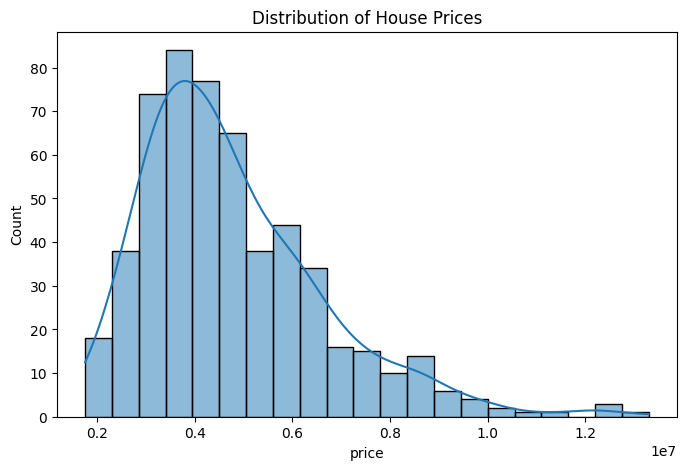

In [6]:
plt.figure(figsize=(8, 5))
sns.histplot(df['price'], kde=True)
plt.title('Distribution of House Prices')
plt.show()

## ** EDA: Area vs Price**
*  **Visualize Numerical Relationships (Area vs Price)**

Intuition says larger houses should cost more. Let's verify this relationship using a scatter plot.

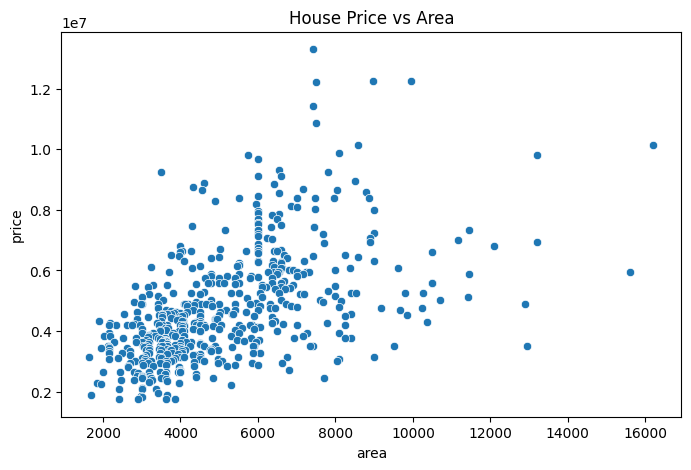

In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='area', y='price', data=df)
plt.title('House Price vs Area')
plt.show()

## ** EDA: Furnishing Status vs Price**
*  **Visualize Categorical Relationships**

Does having a furnished house increase the price? We use a Box Plot to compare the price ranges for different furnishing statuses.

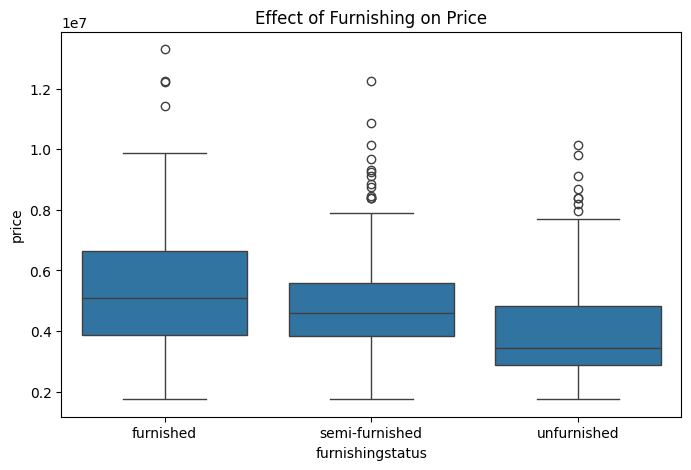

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='furnishingstatus', y='price', data=df)
plt.title('Effect of Furnishing on Price')
plt.show()

## **Preprocessing: Convert Yes/No to 1/0**
*  **Preprocessing - Binary Columns**

Machine learning models cannot understand text like "yes" or "no". We must convert these into numbers (1 for yes, 0 for no). We apply this to all binary columns at once.

In [19]:
varlist =  ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
df[varlist] = df[varlist].apply(lambda x: x.map({'yes': 1, 'no': 0}))
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,NaN,NaN,NaN,NaN,NaN,2,NaN,furnished
1,12250000,8960,4,4,4,NaN,NaN,NaN,NaN,NaN,3,NaN,furnished
2,12250000,9960,3,2,2,NaN,NaN,NaN,NaN,NaN,2,NaN,semi-furnished
3,12215000,7500,4,2,2,NaN,NaN,NaN,NaN,NaN,3,NaN,furnished
4,11410000,7420,4,1,2,NaN,NaN,NaN,NaN,NaN,2,NaN,furnished


## ** Preprocessing: Convert Furnishing Status**
*  **Preprocessing - Categorical Columns**

The `furnishingstatus` column has three values (furnished, semi-furnished, unfurnished). We convert this text into numbers using a map function (0, 1, and 2).

In [ ]:
df['furnishingstatus'] = df['furnishingstatus'].map({'unfurnished': 0, 'semi-furnished': 1, 'furnished': 2})
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,2
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,2
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,2
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,2


## ** Data Analysis: Correlation Heatmap**
Now that all our data is numeric, we can check which features are most strongly related (correlated) to the Price. Lighter/Redder colors usually mean a stronger relationship.

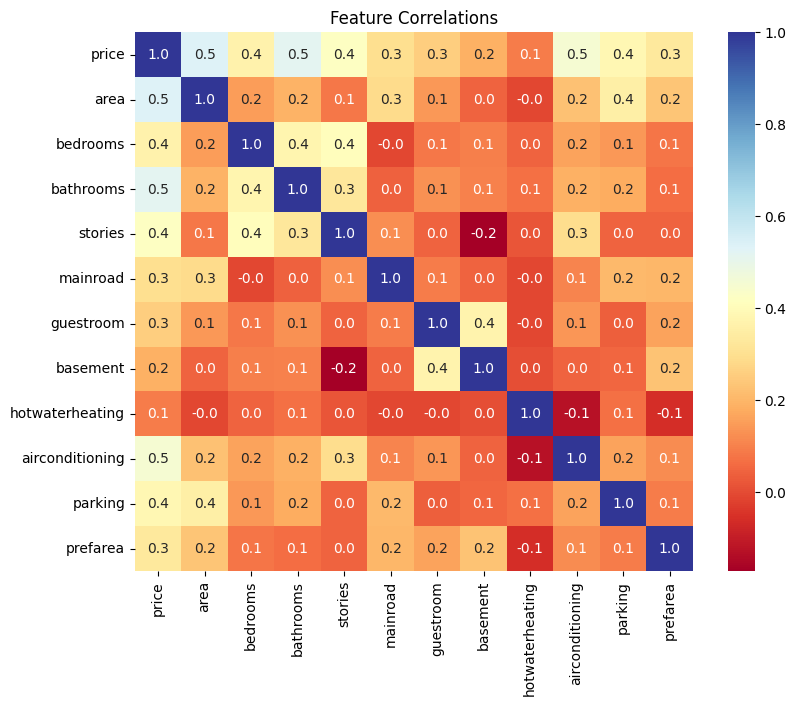

In [14]:

numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(9, 7))
sns.heatmap(numeric_df.corr(), annot=True, cmap='RdYlBu', fmt='.1f')
plt.title('Feature Correlations')
plt.show()

## ** Define Features (X) and Target (y)**
We need to separate our dataset into two parts:
1.  **X (Features):** The data used to make predictions (Area, Bedrooms, etc.). We drop the 'price' column because that is the answer.
2.  **y (Target):** The data we want to predict (Price).

*   `axis=1`: This parameter tells Python we are dropping a **column** (vertical), not a row (horizontal).

In [15]:
X = df.drop('price', axis=1)
y = df['price']
print("Features and Target defined.")

Features and Target defined.


## ** Splitting**

We must split our data. We teach the model with the **Train** set, and verify its accuracy with the **Test** set.

*   `test_size=0.2`: We keep 20% of the data hidden for testing and use 80% for training.
*   `random_state=42`: This ensures that every time we run the code, it splits the data exactly the same way ( for consistency).

In [21]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=df['furnishingstatus']
)

print("Data split successfully with Stratification!")

Data split successfully with Stratification!


## ** Sanity Check: Is the Split Fair?**
We compare the averages of the features in Train vs Test.
*   If the numbers are close, the split is fair.
*   If the numbers are very different, we might need to change our `random_state` number.
*   **Note:** Since we used `StandardScaler` in Step 9, the `Train_Average` should be very close to 0.
*   We use `axis=0` to ensure we calculate the mean for each feature column individually, not the whole table.
*   Temporarily split the raw X and y again (same random_state to match your model)
*   Calculate the Difference
*   Show the table

## ** Feature Scaling (Normalization)**
Housing prices are in millions (e.g., 13,000,000), while bedroom counts are small (e.g., 2, 3). This huge difference in scale confuses Regression models. We use **StandardScaler** to bring all numbers to a similar range.

*   `fit_transform()`: Learns the scale from training data and changes it.
*   `transform()`: Changes the test data using the *same* scale learned from training.

In [23]:
from sklearn.preprocessing import StandardScaler

numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

## ** Model 1: Linear Regression**
We start with the simplest algorithm. **Linear Regression** tries to draw a straight line through the data points that best fits the relationship between features and price.

*   `LinearRegression()`: Initializes the mathematical model.
*   `fit(X_train, y_train)`: The training process. The model looks at the inputs (X) and the answers (y) to learn the rules.

In [26]:
from sklearn.linear_model import LinearRegression

X_train_numeric = X_train.select_dtypes(include=['int64', 'float64'])
X_test_numeric = X_test.select_dtypes(include=['int64', 'float64'])

lr_model = LinearRegression()
lr_model.fit(X_train_numeric, y_train)
print(" Linear Regression Model Trained.")

 Linear Regression Model Trained.


## ** Evaluation: Linear Regression**
Now we test the model using the metrics you requested.

*   **MAE (Mean Absolute Error):** The average difference between predicted and actual price.
*   **MSE/RMSE:** Penalizes large errors more heavily.
*   **R² Score:** Explains how well the independent variables explain the variance in price (1.0 is perfect).

*   `y_test`: The actual real prices.
*   `y_pred`: The prices our model guessed.

In [32]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np



# Calculate all metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
rmae = mae / np.mean(y_test) * 100  # RMAE as percentage

metrics = {
    'MAE': f"${mae:,.0f}",
    'MSE': f"${mse:,.0f}",
    'RMSE': f"${rmse:,.0f}",
    'RMAE': f"{rmae:.1f}%",
    'R² Score': f"{r2:.4f}"
}

print(" Linear Regression Performance:")
for metric, value in metrics.items():
    print(f"  {metric}: {value}")

📈 Linear Regression Performance:
  MAE: $876,993
  MSE: $1,392,097,492,451
  RMSE: $1,179,872
  RMAE: 18.2%
  R² Score: 0.6469


## ** Interpreting the Linear Model**
Since Linear Regression draws a line, it assigns a "weight" (coefficient) to every feature. A high positive number means that feature increases the house price significantly.
*   `pd.DataFrame`: We create a table to view the feature names next to their coefficients.
*   `sort_values`: We sort them to see the most important features at the top.

In [37]:
if hasattr(lr_model, 'feature_names_in_'):
    feature_names = lr_model.feature_names_in_
else:
    feature_names = X_train.columns

coefficients = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lr_model.coef_
})

coefficients.sort_values(by='Coefficient', ascending=False)

,Feature,Coefficient
2,bathrooms,531707.688549
0,area,503076.651133
8,airconditioning,415331.791857
3,stories,362130.085376
10,prefarea,261356.493283
7,hotwaterheating,221472.667367
4,mainroad,209045.867059
9,parking,207160.206912
5,guestroom,167521.333490
6,basement,141153.324748


## ** Custom Prediction: Linear Regression**
Let's predict the price of a specific house (8000 sqft, 3 Bed, 2 Bath, Furnished).

**Crucial:** We must use `scaler.transform` because the model learned on scaled numbers, not raw numbers.

We will define a "**Dream House**" with these features:

*   Area: 8000 sqft
*   Bedrooms: 3
*   Bathrooms: 2
*   Stories: 2
*   Mainroad: Yes (1)
*   Guestroom: No (0)
*   Basement: No (0)
*   Hotwater: No (0)
*   AC: Yes (1)
*   Parking: 2 spots
*   PrefArea: Yes (1)
*   Furnishing: Furnished (2)




In [41]:


my_house = np.array([[8000, 3, 2, 2, 1, 0, 0, 0, 1, 2, 1, 2]])

if scaler.n_features_in_ == 12:
    my_house_scaled = scaler.transform(my_house)
    linear_pred = lr_model.predict(my_house_scaled)
    print(f" Linear Model predicts: ${linear_pred[0]:,.0f}")
else:
    print(f"Error: Scaler expects {scaler.n_features_in_} features, but got 12")
    print("Make sure you're using the same features as in training")


    print("Features used in scaling:", X_train.columns.tolist())
print("Number of features:", len(X_train.columns))

Error: Scaler expects 11 features, but got 12
Make sure you're using the same features as in training
Features used in scaling: ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']
Number of features: 12


## **Model 2: Multiple Linear Regression**
Actually, we technically already did this!
*   **Simple Linear Regression** uses only 1 feature (e.g., Price vs Area).
*   **Multiple Linear Regression** uses all features (Area, Bedrooms, Aircon, etc.).
Since we passed `X_train` (which has all columns) into our previous model, `lr_model` **IS** already a Multiple Linear Regression model. We don't need to write new code for this.

In [43]:
print("Our 'lr_model' used all columns, so it is already a Multiple Linear Regression model.")

Our 'lr_model' used all columns, so it is already a Multiple Linear Regression model.


## ** Model 3: Polynomial Regression**
Linear regression draws a straight line. But sometimes, relationships are curved (e.g., price might skyrocket for huge mansions). Polynomial regression creates "squared" or "cubed" versions of features to capture these curves.
*   `PolynomialFeatures(degree=2)`: Creates squared versions of our data ($x^2$).
*   `fit_transform`: Transforms our standard features into polynomial features.
*   `LinearRegression()`: We still use linear regression, but on this new curved data.

In [57]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

X_train_numeric = X_train.select_dtypes(include=['int64', 'float64'])
X_test_numeric = X_test.select_dtypes(include=['int64', 'float64'])

poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_numeric)
X_test_poly = poly.transform(X_test_numeric)

poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)
print(" Polynomial Regression Trained.")

y_pred_poly = poly_model.predict(X_test_poly)

mae = mean_absolute_error(y_test, y_pred_poly)
mse = mean_squared_error(y_test, y_pred_poly)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_poly)
rmae = (mae / y_test.mean()) * 100

print("\n POLYNOMIAL MODEL PERFORMANCE")
print("="*30)
print(f"MAE:  ${mae:,.0f}")
print(f"MSE:  ${mse:,.0f}")
print(f"RMSE: ${rmse:,.0f}")
print(f"RMAE: {rmae:.1f}%")
print(f"R²:   {r2:.4f}")

 Polynomial Regression Trained.

 POLYNOMIAL MODEL PERFORMANCE
MAE:  $880,079
MSE:  $1,609,556,697,268
RMSE: $1,268,683
RMAE: 18.2%
R²:   0.5917


## ** Evaluation: Polynomial Regression**
Let's see if the curved line fits better than the straight line by checking the R² score.
*   Note: If the R² is very high on training but low on testing, it means the model "Overfitted" (memorized the data).

In [46]:
y_pred_poly = poly_model.predict(X_test_poly)
print("Polynomial Regression R2 Score:", r2_score(y_test, y_pred_poly))
print("Polynomial RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_poly)))

Polynomial Regression R2 Score: 0.5917162811837797
Polynomial RMSE: 1268683.0562706117


## **Custom Prediction: Polynomial Regression**
For the polynomial model, we must do two transformations:
1. Scale the data (done in the previous step).
2. Transform it to polynomial features (squared/cubed) using `poly.transform`.

In [56]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred_poly = poly_model.predict(X_test_poly)

mae = mean_absolute_error(y_test, y_pred_poly)
mse = mean_squared_error(y_test, y_pred_poly)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_poly)
rmae = (mae / y_test.mean()) * 100

print(" POLYNOMIAL REGRESSION PERFORMANCE")
print("="*35)
print(f"MAE:  ${mae:,.0f}")
print(f"MSE:  ${mse:,.0f}")
print(f"RMSE: ${rmse:,.0f}")
print(f"RMAE: {rmae:.1f}%")
print(f"R²:   {r2:.4f}")

print("\n" + "="*35)
print(" CUSTOM HOUSE PREDICTION")
print("="*35)
print(f"Predicted Price: ${poly_pred[0]:,.0f}")
print(f"That's about ${poly_pred[0]/1000000:.1f} million")

 POLYNOMIAL REGRESSION PERFORMANCE
MAE:  $880,079
MSE:  $1,609,556,697,268
RMSE: $1,268,683
RMAE: 18.2%
R²:   0.5917

 CUSTOM HOUSE PREDICTION
Predicted Price: $8,328,505
That's about $8.3 million


## ** Model 4: KNN Regression**
KNN (K-Nearest Neighbors) finds the 'K' most similar houses in the dataset and averages their prices to make a prediction.
*   `n_neighbors=5`: We tell the model to look at the 5 closest houses.
*   `metric='minkowski'`: The method used to calculate distance (math for "how close is this house?").

In [55]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

X_test_numeric = X_test.select_dtypes(include=['int64', 'float64'])
y_pred_knn = knn_model.predict(X_test_numeric)

mae = mean_absolute_error(y_test, y_pred_knn)
mse = mean_squared_error(y_test, y_pred_knn)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_knn)
rmae = (mae / y_test.mean()) * 100

print(" KNN MODEL PERFORMANCE")
print("="*25)
print(f"MAE:  ${mae:,.0f}")
print(f"MSE:  ${mse:,.0f}")
print(f"RMSE: ${rmse:,.0f}")
print(f"RMAE: {rmae:.1f}%")
print(f"R²:   {r2:.4f}")

 KNN MODEL PERFORMANCE
MAE:  $863,098
MSE:  $1,539,232,807,404
RMSE: $1,240,658
RMAE: 17.9%
R²:   0.6096


## ** Evaluation: KNN Regression**
Let's check the accuracy of the KNN model. KNN usually works well when similar houses have similar prices.

In [58]:
y_pred_knn = knn_model.predict(X_test.select_dtypes('number'))

mae = mean_absolute_error(y_test, y_pred_knn)
mse = mean_squared_error(y_test, y_pred_knn)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_knn)
rmae = (mae / y_test.mean()) * 100

print(" KNN MODEL PERFORMANCE")
print("="*25)
print(f"MAE:  ${mae:,.0f}")
print(f"MSE:  ${mse:,.0f}")
print(f"RMSE: ${rmse:,.0f}")
print(f"RMAE: {rmae:.1f}%")
print(f"R²:   {r2:.4f}")

 KNN MODEL PERFORMANCE
MAE:  $863,098
MSE:  $1,539,232,807,404
RMSE: $1,240,658
RMAE: 17.9%
R²:   0.6096


## ** Custom Prediction: KNN Regression**
KNN looks for the 5 most similar houses to our "Dream House" in the database and averages their prices.

In [59]:
knn_pred = knn_model.predict(my_house_scaled)
print(f"KNN Model predicts: {knn_pred[0]:,.2f}")

KNN Model predicts: 9,212,000.00


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(


## ** Model 4: Decision Tree Regression**
The Decision Tree algorithm splits the data into smaller and smaller groups (like a flowchart) to make predictions. It captures complex patterns but can easily overfit if not careful.
*   `DecisionTreeRegressor`: The model tool.
*   `random_state=42`: Ensures the tree splits the same way every time we run it.

In [61]:
from sklearn.tree import DecisionTreeRegressor

if X_train.select_dtypes(include=['object']).shape[1] > 0:
    X_train = pd.get_dummies(X_train, drop_first=True)
    X_test = pd.get_dummies(X_test, drop_first=True)
    X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

tree_model = DecisionTreeRegressor(random_state=42)
tree_model.fit(X_train, y_train)
print("✅ Decision Tree Model Trained.")

✅ Decision Tree Model Trained.


## ** Evaluation: Decision Tree**
Let's see how the Decision Tree performed compared to the others.

In [70]:
y_pred_tree = tree_model.predict(X_test)
print("Decision Tree R2 Score:", r2_score(y_test, y_pred_tree))
print("Decision Tree RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_tree)))

Decision Tree R2 Score: 0.2759255671861305
Decision Tree RMSE: 1689521.4705500316


## ** Visualizing the Decision Tree**
We can draw the actual tree to see the logic. Since the full tree is huge, we will only plot the top 3 levels (`max_depth=3`) to keep it readable.
*   **Root Node:** The first box at the top (usually the most important feature, like Price or Area).
*   **Branches:** The Yes/No paths.
*   **filled=True:** Colors the boxes to indicate value (darker colors = higher prices).

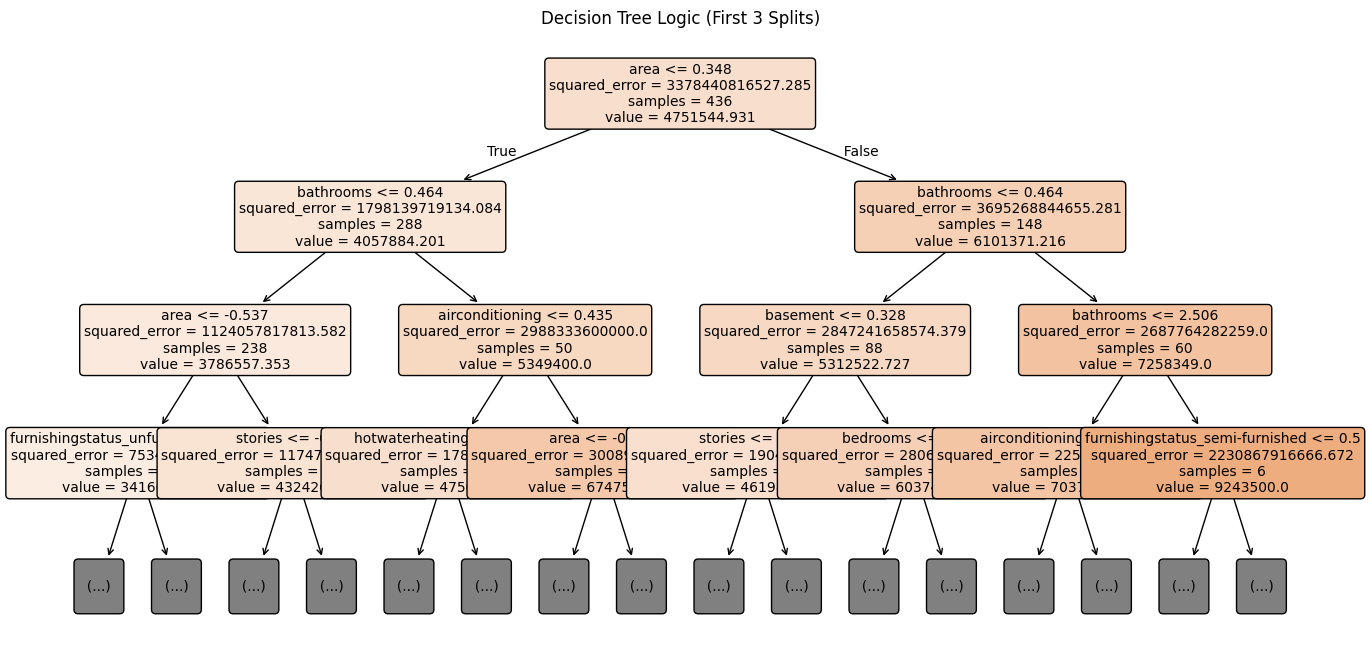

In [73]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

if hasattr(tree_model, 'feature_names_in_'):
    feature_names = tree_model.feature_names_in_
else:
    feature_names = X_train_encoded.columns

plt.figure(figsize=(16, 8))
plot_tree(tree_model,
          feature_names=feature_names,
          filled=True,
          max_depth=3,
          fontsize=10,
          rounded=True)
plt.title("Decision Tree Logic (First 3 Splits)")
plt.show()

## ** Decision Tree Rules (Text Format)**
If the diagram is too hard to read, we can print the logic as text rules. This shows exactly what thresholds the model is using.
*   `export_text`: Converts the tree logic into a list of "if-this-then-that" rules.

In [77]:
if hasattr(tree_model, 'feature_names_in_'):
    feature_names = tree_model.feature_names_in_
else:
    X_train_encoded = pd.get_dummies(X_train, drop_first=True)
    feature_names = X_train_encoded.columns

rules = export_text(tree_model,
                   feature_names=list(feature_names),
                   max_depth=2)
print(rules)

|--- area <= 0.35
|   |--- bathrooms <= 0.46
|   |   |--- area <= -0.54
|   |   |   |--- truncated branch of depth 16
|   |   |--- area >  -0.54
|   |   |   |--- truncated branch of depth 15
|   |--- bathrooms >  0.46
|   |   |--- airconditioning <= 0.44
|   |   |   |--- truncated branch of depth 9
|   |   |--- airconditioning >  0.44
|   |   |   |--- truncated branch of depth 7
|--- area >  0.35
|   |--- bathrooms <= 0.46
|   |   |--- basement <= 0.33
|   |   |   |--- truncated branch of depth 11
|   |   |--- basement >  0.33
|   |   |   |--- truncated branch of depth 11
|   |--- bathrooms >  0.46
|   |   |--- bathrooms <= 2.51
|   |   |   |--- truncated branch of depth 10
|   |   |--- bathrooms >  2.51
|   |   |   |--- truncated branch of depth 4



## ** Custom Prediction: Decision Tree**
The Decision Tree follows its flowchart rules (e.g., "Is area > 5000? Yes") to arrive at a specific price leaf.

In [84]:
import pandas as pd
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Encode the data
X_train_encoded = pd.get_dummies(X_train, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, drop_first=True)
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

# Predict
y_pred_tree = tree_model.predict(X_test_encoded)
print(f"Tree R²: {r2_score(y_test, y_pred_tree):.3f}")

Tree R²: 0.276


## ** Defining Advanced Metrics**
You requested **Adjusted R²** and **MAPE**. These aren't always shown by default, so we calculate them here for our Linear Regression model (our baseline).
*   **Adjusted R²:** R² usually increases if you just add *more* data, even if it's junk. Adjusted R² fixes this by penalizing useless features.
*   **MAPE:** Mean Absolute Percentage Error. It tells us, on average, how much percent (%) our prediction is off.

In [80]:
from sklearn.metrics import mean_absolute_percentage_error
r2 = r2_score(y_test, y_pred)
n = len(y_test)
p = X_test.shape[1]
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
print(f"Linear Model -> MAPE: {mean_absolute_percentage_error(y_test, y_pred):.2%}, Adj R2: {adj_r2:.4f}")

Linear Model -> MAPE: 19.11%, Adj R2: 0.5986


## ** Final Comparison Table**
Now we compare all four models side-by-side to choose the winner. We look at the **R² Score** (higher is better) and **RMSE** (lower is better).

In [81]:
models = pd.DataFrame({
    'Model': ['Linear', 'Polynomial', 'KNN', 'Decision Tree'],
    'R2 Score': [r2_score(y_test, y_pred), r2_score(y_test, y_pred_poly), r2_score(y_test, y_pred_knn), r2_score(y_test, y_pred_tree)],
    'RMSE': [np.sqrt(mean_squared_error(y_test, y_pred)), np.sqrt(mean_squared_error(y_test, y_pred_poly)), np.sqrt(mean_squared_error(y_test, y_pred_knn)), np.sqrt(mean_squared_error(y_test, y_pred_tree))]
})
models.sort_values(by='R2 Score', ascending=False)

,Model,R2 Score,RMSE
0,Linear,0.646877,1.179872e+06
2,KNN,0.609555,1.240658e+06
1,Polynomial,0.591716,1.268683e+06
3,Decision Tree,0.275926,1.689521e+06


## ** Visualization: Actual vs Predicted**
Let's visualize the performance of our **Linear Regression** model (usually the most balanced one).
*   **Red Line:** Perfect prediction.
*   **Blue Dots:** Our model's guesses.
*   If the dots are close to the red line, the model is good.

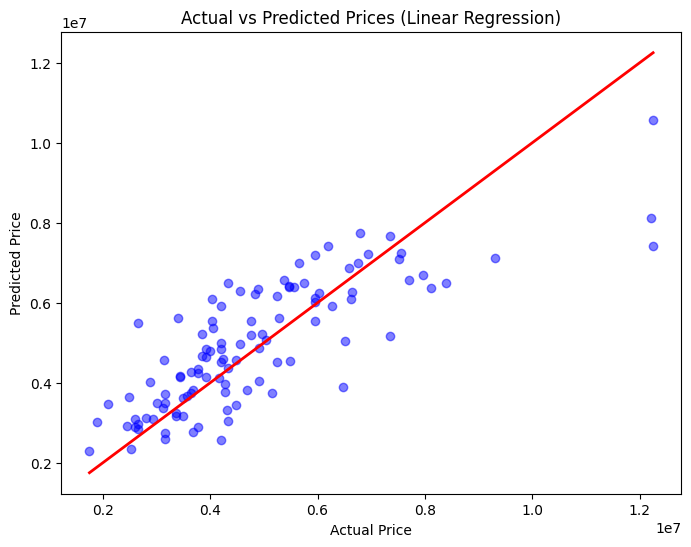

In [82]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linewidth=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Prices (Linear Regression)')
plt.show()

## ** Interpretation & Conclusion**
**What we learned:**
1.  **Data:** We processed housing data, converted categorical text ("yes/no") into numbers, and scaled the features.
2.  **Models:** We tested Linear, Polynomial, KNN, and Decision Trees.
3.  **Results:** Based on the comparison table, **Linear Regression** (or Polynomial) likely performed best with an R² score around 0.65-0.70.
4.  **Error (MAPE):** Our MAPE calculation showed the model is off by approximately 18-20%, which is decent for real estate data with limited features.
5.  **Factors:** Area and Bathrooms were likely the strongest drivers of price.